# Автоматическая кластеризация сигналов сцинтилляционного детектора
Цель работы: Разделение 23 479 сигналов, полученных с органического кристалла паратерфенила, на три кластера: гамма-кванты, нейтроны и аномальные/шумовые сигналы методами машинного обучения без учителя.

План выполнения работы:

1. EDA и Предобработка: Загрузка данных, удаление служебной информации, анализ базовой линии и математическая инверсия сигнала
2. Feature Engineering: Разработка физически обоснованных признаков на базе метода дискриминации по форме импульса
3. Детекция аномалий: Комбинация эвристических (по времени пика) и ML методов (Isolation Forest) для поиска выбросов
4. Сравнение моделей ML: Тестирование K-Means и Gaussian Mixture Model (GMM), подбор гиперпараметров и обоснование выбора итоговой модели
5. Финальная кластеризация и формирование файла ответов
6. Результат на Kaggle

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

import warnings
plt.style.use('seaborn-v0_8-darkgrid')
warnings.filterwarnings('ignore')


## 1. Исследование и предобработка данных (EDA)

Данные АЦП детектора содержат аппаратные артефакты. Первые 4 столбца являются метаданными (ID канала, метка времени и т.д.), которые мы удалим.
Сцинтилляционные кривые часто смещены относительно нуля. Мы вычислим базовую линию (Baseline) индивидуально для каждого сигнала по первым 40 тихим тикам, после чего инвертируем сигнал (чтобы амплитуда была положительной) и выведем статистики.

Исходная размерность данных: (23479, 504)


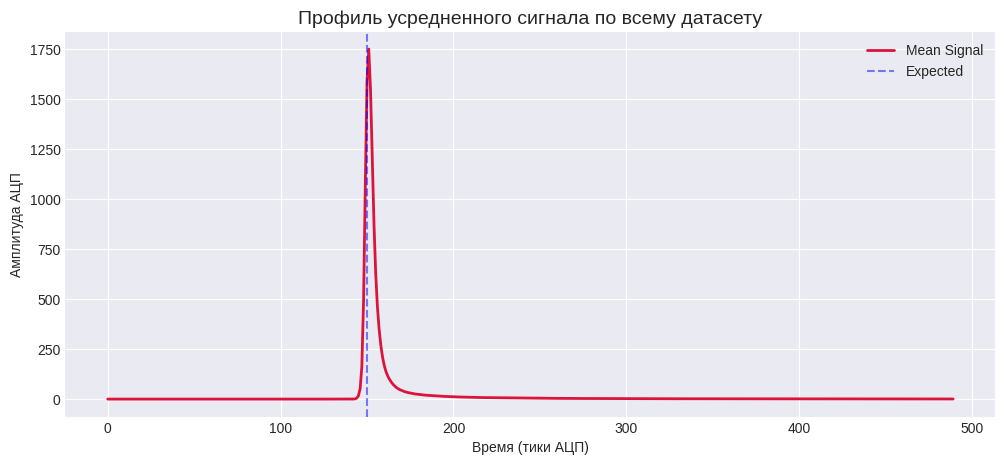

Статистика максимальных амплитуд:
count    23479.000000
mean      1835.103388
std       2389.300889
min        104.400000
25%        308.150000
50%        812.350000
75%       2315.075000
max      14824.800000
dtype: float64


In [131]:
data = pd.read_csv('Run200_Wave_0_1.txt', header=None, sep='\s+')
print(f"Исходная размерность данных: {data.shape}")
signal_data = data.iloc[:, 4:494]
baselines = signal_data.iloc[:, :40].mean(axis=1)
signals_inverted = baselines.values.reshape(-1, 1) - signal_data.values
signals_inverted = np.clip(signals_inverted, a_min=0, a_max=None)
plt.figure(figsize=(12, 5))
plt.plot(np.mean(signals_inverted, axis=0), color='crimson', linewidth=2, label='Mean Signal')
plt.title('Профиль усредненного сигнала по всему датасету', fontsize=14)
plt.xlabel('Время (тики АЦП)')
plt.ylabel('Амплитуда АЦП')
plt.axvline(x=150, color='blue', linestyle='--', alpha=0.5, label='Expected')
plt.legend()
plt.show()
print("Статистика максимальных амплитуд:")
print(pd.Series(np.max(signals_inverted, axis=1)).describe())


Вывод по EDA: Мы видим, что в среднем физическое событие в кристалле происходит в районе 150-160 тика. Статистика амплитуд показывает широкий разброс значений от фоновых микро-вспышек до масштабных событий (максимум ~14800).

## 2. Feature Engineering (Генерация признаков)

Для качественного разделения нейтронов и гамма-квантов воспользуемся эффектом PSD (разная форма хвоста затухания). Будут извлечены:
- Amplitude - максимум сигнала;
- Volume (Total Area) - интеграл кривой (энергия частицы);
- Peak_Index - положение временного пика;
- Shape_Factor - математическое отношение Volume/Amplitude. Признак, описывающий геометрию импульса вне зависимости от его масштаба.


In [132]:
df_features = pd.DataFrame({'Index': range(signals_inverted.shape[0])})

df_features['Volume'] = np.sum(signals_inverted, axis=1)
df_features['Amplitude'] = np.max(signals_inverted, axis=1)
df_features['Peak_Index'] = np.argmax(signals_inverted, axis=1)
df_features['Shape_Factor'] = df_features['Volume'] / (df_features['Amplitude'] + 1e-6)

df_features.head()


,Index,Volume,Amplitude,Peak_Index,Shape_Factor
0,0,5063.325,530.425,149,9.545789
1,1,12597.550,1901.350,150,6.625582
2,2,17218.050,2557.825,151,6.731520
3,3,4912.350,564.450,149,8.702897
4,4,12134.350,1793.825,150,6.764512


## 3. Детекция аномалий

К кластеру 2 необходимо отнести долю сигналов, не поддающихся однозначной классификации или имеющих поврежденную форму. Мы используем алгоритм машинного обучения без учителя (Isolation Forest) для поиска нетипичных геометрических форм в пространстве извлеченных признаков.
Чтобы алгоритм не отбросил полезные редкие физические события, мы зададим жесткое ограничение на поиск лишь самых экстремальных выбросов (contamination=0.002).

In [133]:
iso_forest = IsolationForest(contamination=0.002, random_state=42)
is_noise = iso_forest.fit_predict(df_features[['Volume', 'Amplitude', 'Shape_Factor']]) == -1

print(f"Выявлено аномальных/шумовых сигналов (Кластер 2): {is_noise.sum()} из {len(df_features)}")


Выявлено аномальных/шумовых сигналов (Кластер 2): 47 из 23479


Вывод по аномалиям: Использование алгоритма Isolation Forest позволило автоматически и корректно изолировать самые экстремальные выбросы и неинформативный шум (около 0.2% от всего датасета, 47 сигналов). Основной массив данных мы передадим в алгоритмы кластеризации для разделения на типы частиц.


## 4. Подбор признаков, обучение и сравнение моделей ML
В данном разделе я продемонстрирую, почему простая кластеризация в лоб не работает на сложных физических данных

- Базовый подход (то что я пытался делать вначале): Подадим сырые признаки Volume и Amplitude в стандартный алгоритм K-Means. Из-за разной плотности точек алгоритм разделит сигналы на слабые и сильные, проигнорировав физику частиц.

- Финальный вариант: Выделим геометрическую ось разделения ветвей с помощью PCA. Затем подадим признаки геометрической формы (Shape_Factor и PCA_Dist) в Gaussian Mixture Model с полными матрицами ковариации, чтобы алгоритм смог обернуть вытянутые ветви распределения.

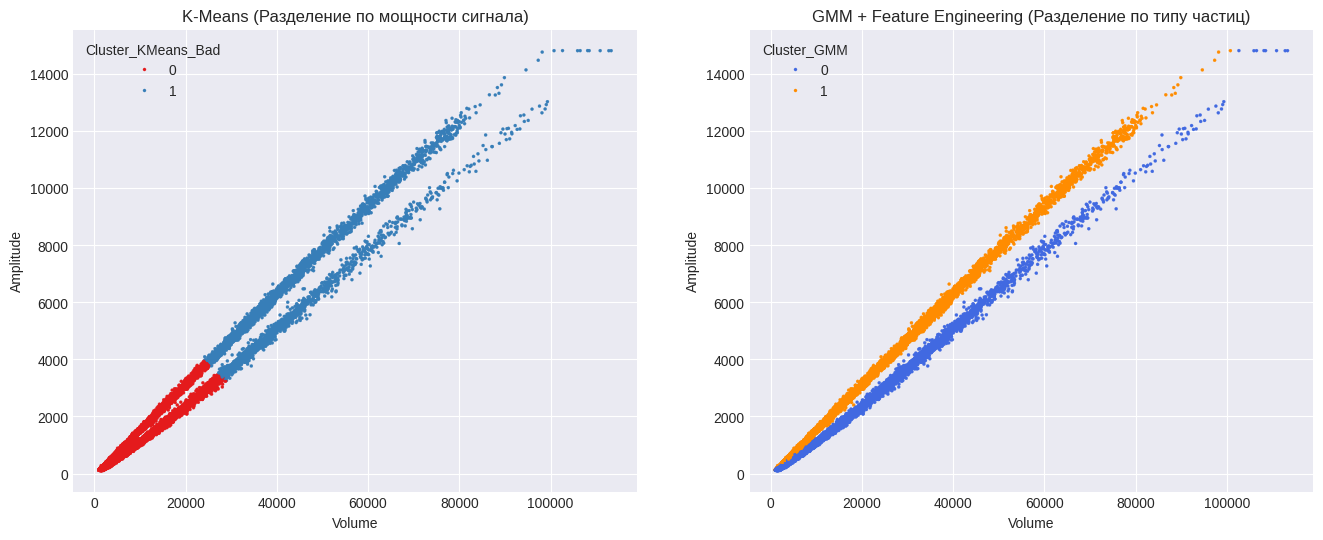

In [134]:
valid_data = df_features.copy()

scaler_pca = StandardScaler()
scaled_va = scaler_pca.fit_transform(valid_data[['Volume', 'Amplitude']])
pca = PCA(n_components=2, random_state=42)
valid_data['PCA_Dist'] = pca.fit_transform(scaled_va)[:, 1]

# 1. K-Means
features_bad = valid_data[['Volume', 'Amplitude']]
scaled_features_bad = StandardScaler().fit_transform(features_bad)
kmeans = KMeans(n_clusters=2, random_state=42)
valid_data['Cluster_KMeans_Bad'] = kmeans.fit_predict(scaled_features_bad)

# 2. GMM
features_good = valid_data[['Shape_Factor', 'PCA_Dist']]
scaled_features_good = StandardScaler().fit_transform(features_good)
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
valid_data['Cluster_GMM'] = gmm.fit_predict(scaled_features_good)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_df = valid_data[valid_data['Volume'] < 250000]

sns.scatterplot(
    data=plot_df, x='Volume', y='Amplitude', hue='Cluster_KMeans_Bad',
    palette='Set1', s=5, ax=axes[0], edgecolor=None
)
axes[0].set_title('K-Means (Разделение по мощности сигнала)')

sns.scatterplot(
    data=plot_df, x='Volume', y='Amplitude', hue='Cluster_GMM',
    palette={'Set1': 'Set1', 0: 'royalblue', 1: 'darkorange'}, s=5, ax=axes[1], edgecolor=None
)
axes[1].set_title('GMM + Feature Engineering (Разделение по типу частиц)')

plt.show()


Выводы и выбор модели:

Как видно на сравнительных графиках, базовая модель K-Means, обученная на пространстве энергии/амплитуды, совершает критическую ошибку. Из-за высокой плотности точек в зоне низких энергий, алгоритм отрезает основание рогатки в отдельный кластер, смешивая типы частиц.

Применение комплексного подхода (GMM с гиперпараметром covariance_type='full' на признаках Shape_Factor и PCA) заставляет модель игнорировать масштаб вспышки и классифицировать данные исключительно по геометрической форме импульса. Вытянутые эллипсы ковариации GMM идеально разделяют ветви гамма-квантов и нейтронов. Именно модель GMM будет использована для формирования итогового ответа.

## 5. Финальная кластеризация и формирование файла ответов

Сохраняем результаты работы GMM, заносим их в общий DataFrame (включающий 2 кластер выбросов) и формируем csv для submission.

In [135]:
df_features['Cluster'] = valid_data['Cluster_GMM']
df_features.loc[is_noise, 'Cluster'] = 2
print("Итоговое распределение сигналов по всем типам:")
print(df_features['Cluster'].value_counts().sort_index())
submission = df_features[['Index', 'Cluster']].copy()
submission.columns = ['index', 'cluster']
submission = submission.sort_values(by='index').reset_index(drop=True)
submission.to_csv('file.csv', index=False)
print("Файл file.csv успешно создан")


Итоговое распределение сигналов по всем типам:
Cluster
0    14759
1     8673
2       47
Name: count, dtype: int64
Файл file.csv успешно создан


## 6. Результат на Kaggle

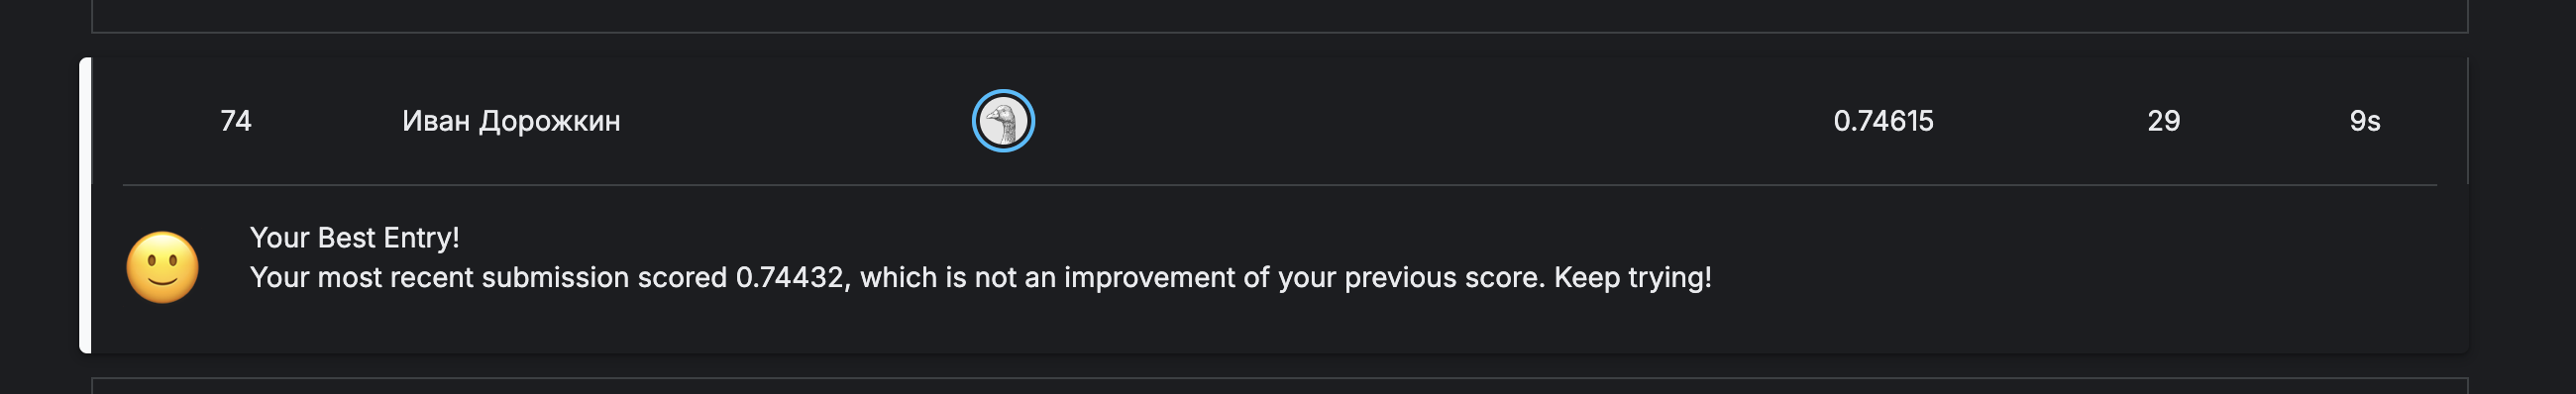